<a href="https://colab.research.google.com/github/WVF-1/The-Full-Monty/blob/main/FULPs%20FULP8%20v0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FULPs FULP Eight — Prototype v0

**A proof-of-concept implementation of FULP Eight: Encephalon (Model Building).**

This notebook implements a grid-based architecture — the **Encephalon** — composed of
localized expert nodes called **Skepsis**. Each Skepsi contains nine specialised
microcells inspired by Random Forest experts. Spatial attention expands progressively
outward (**Progressive Spatial Attention**), and conflicted Skepsis initiate a
**Peer Review Process** among their Von Neumann neighbours. Disagreement is quantified
as **Contradiction Energy**.

The Void Stabilizer (FULP 1) is preserved from prior FULPs work and repurposed
here as the Novelty and Anomaly detection channel inside each Skepsi.

---

**Experiments**: Four single-run experiments on cumulative synthetic datasets
(S → M → L → XL). No 50-run study in this version.

**Goal**: Determine whether contradiction minimisation and Progressive Spatial
Attention produce meaningful, interpretable behaviour before scaling Encephalon.


In [53]:
# ── Cell 1: Install ─────────────────────────────────────────────────────────
import subprocess, sys
for pkg in ['torch', 'scipy', 'scikit-learn', 'pandas', 'matplotlib', 'seaborn']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'],
                   capture_output=True)
print('Packages ready.')


Packages ready.


In [54]:
# ── Cell 2: Imports and Configuration ───────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import torch
import torch.nn as nn
from scipy.linalg import cholesky
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from collections import Counter

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

OUT_DIR = '/content' if os.path.exists('/content') else '.'

# ── Grid ───────────────────────────────────────────────────────────────────────
GRID_H, GRID_W   = 9, 9          # 81 Skepsis total
SUBSPACE_FRAC    = 0.6           # fraction of features each Skepsi sees

# ── Confidence / Contradiction thresholds ────────────────────────────────────
CONF_ACCEPT      = 0.60          # acceptance threshold
CONT_ACCEPT      = 0.35          # acceptance threshold
CONF_EMERGENCY   = 0.50          # emergency expansion trigger
CONT_EMERGENCY   = 0.30          # emergency expansion trigger

# ── VoidStabilizer (FULP 1, preserved from prior work) ───────────────────────
VOID_HIDDEN      = 16
EA_TARGET_STD    = 0.3
EA_WEIGHT        = 0.5
VOID_EPOCHS      = 100
VOID_BATCH       = 128

# ── Baselines ─────────────────────────────────────────────────────────────────
RF_N_ESTIMATORS  = 100
GNN_K            = 5
GNN_EPOCHS       = 100
GNN_HIDDEN       = 32
GNN_LR           = 1e-3

# ── Experiment ────────────────────────────────────────────────────────────────
GLOBAL_SEED      = 42
TEST_SIZE        = 0.25
MAX_PSA_LEVELS   = 4

# ── Plotting style ────────────────────────────────────────────────────────────
TIER_COLORS  = {'S': '#4c72b0', 'M': '#55a868', 'L': '#c44e52', 'XL': '#8172b2'}
MODEL_COLORS = {'RF': '#4c72b0', 'GNN': '#55a868', 'FULP8': '#c44e52'}

plt.rcParams.update({
    'font.family':    'monospace',
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize':8,
    'ytick.labelsize':8,
    'legend.fontsize':8,
    'axes.grid':      True,
    'grid.alpha':     0.3,
})

print('Configuration loaded.')
print(f'Grid: {GRID_H}×{GRID_W} = {GRID_H*GRID_W} Skepsis')
print(f'Microcells per Skepsi: 9  |  Max Skepsis: {GRID_H*GRID_W}  |  '
      f'Max Microcells: {GRID_H*GRID_W*9}')


Configuration loaded.
Grid: 9×9 = 81 Skepsis
Microcells per Skepsi: 9  |  Max Skepsis: 81  |  Max Microcells: 729


In [55]:
# ── Cell 3: Synthetic Datasets (S / M / L / XL) ─────────────────────────────
#
# Design principle: each tier is a STRICT SUPERSET of the tier below it.
#   M re-uses the same core linear relationship from S, adds nonlinearity.
#   L re-uses M's relationship, adds temporal / AR(1) structure.
#   XL re-uses L's relationship, adds spatial structure, irrelevant features,
#       and a contradictory zone (scrambled labels in a circular region) —
#       intentionally echoing the perturbation theme from FULPs CA.
#
# T-shirt labels (S/M/L/XL) are used ONLY for human-facing reporting.
# They are NEVER passed into the Encephalon.

TIER_SIZES = {'S': 200, 'M': 400, 'L': 800, 'XL': 1600}


def _gen_S(n, rng):
    f1 = rng.normal(0, 1, n);  f2 = rng.normal(0, 1, n);  f3 = rng.normal(0, 1, n)
    score = 1.5*f1 - 1.2*f2 + 0.3*f3 + rng.normal(0, 0.15, n)
    y = (score > 0).astype(int)
    return pd.DataFrame({'f1':f1,'f2':f2,'f3':f3}), y, score


def _gen_M(n, rng):
    X, _, score = _gen_S(n, rng)
    f4 = rng.normal(0, 1, n);  f5 = rng.normal(0, 1, n)
    score_m = score + 0.8*f4**2 - 0.5*f4*X['f2'].values + rng.normal(0, 0.25, n)
    X['f1'] += rng.normal(0, 0.05, n);  X['f2'] += rng.normal(0, 0.05, n)
    X['f4'] = f4;  X['f5'] = f5
    y = np.where(score_m>0.4, 1, np.where(score_m<-0.4, 0, 2))
    return X, y, score_m


def _gen_L(n, rng):
    f2=rng.normal(0,1,n); f3=rng.normal(0,1,n)
    f4=rng.normal(0,1,n); f5=rng.normal(0,1,n)
    f1=np.zeros(n); f1[0]=rng.normal(0,1)
    for t in range(1,n):
        f1[t] = 0.6*f1[t-1] + 0.4*rng.normal(0,1)       # AR(1) sequence
    f6 = np.roll(f1,1); f6[0] = 0.0                      # explicit lag feature
    score   = 1.5*f1 - 1.2*f2 + 0.3*f3                   # S preserved
    score_m = score + 0.8*f4**2 - 0.5*f4*f2              # M preserved
    score_l = score_m + 0.5*f1*f4 + 0.4*f6 + rng.normal(0, 0.40, n)
    qs = np.quantile(score_l, [0.25,0.5,0.75])
    y = np.digitize(score_l, qs)
    return pd.DataFrame({'f1':f1,'f2':f2,'f3':f3,'f4':f4,'f5':f5,'f6':f6}), y, score_l


def _gen_XL(n, rng):
    X, _, score_l = _gen_L(n, rng)
    xc = rng.uniform(0,10,n);  yc = rng.uniform(0,10,n)
    centers = np.array([[2,2],[8,2],[5,8]])
    d = np.stack([np.hypot(xc-c[0], yc-c[1]) for c in centers], axis=1)
    region = d.argmin(axis=1)
    score_xl = score_l + (region-1.0)*1.2 + rng.normal(0, 0.30, n)
    qs = np.quantile(score_xl, [0.2,0.4,0.6,0.8])
    y = np.digitize(score_xl, qs)
    # Contradictory zone: circular region with scrambled labels
    contra = np.hypot(xc-5, yc-5) < 1.5
    if contra.sum() > 0:
        y[contra] = rng.integers(0, 5, contra.sum())
    X['x_coord'] = xc;  X['y_coord'] = yc
    X['f7_irrelevant'] = rng.normal(0,1,n)
    X['f8_irrelevant'] = rng.uniform(-1,1,n)
    X['contradiction_zone'] = contra.astype(int)   # for analysis only
    return X, y, score_xl


_GENERATORS = {'S':_gen_S, 'M':_gen_M, 'L':_gen_L, 'XL':_gen_XL}


def generate_dataset(tier, n=None, seed=42):
    rng = np.random.default_rng(seed)
    n = n or TIER_SIZES[tier]
    X, y, score = _GENERATORS[tier](n, rng)
    return X.reset_index(drop=True), np.asarray(y), int(np.unique(y).size)


# ── Preview all four tiers ──────────────────────────────────────────────────
print('Dataset tier summary')
print('-'*55)
print(f'  {"Tier":<5}  {"Rows":<6}  {"Features":<10}  {"Classes":<9}  {"Features"}')
print('-'*55)
for tier in ['S','M','L','XL']:
    X, y, k = generate_dataset(tier)
    print(f'  {tier:<5}  {len(X):<6}  {X.shape[1]:<10}  {k:<9}  {list(X.columns)}')
print()
print('Key design properties:')
print('  S  — simple linear, 2 classes')
print('  M  — nonlinear + mild noise, 3 classes (superset of S)')
print('  L  — AR(1) temporal structure, 4 classes (superset of M)')
print('  XL — spatial regions, contradictory zone, 5 classes (superset of L)')


Dataset tier summary
-------------------------------------------------------
  Tier   Rows    Features    Classes    Features
-------------------------------------------------------
  S      200     3           2          ['f1', 'f2', 'f3']
  M      400     5           3          ['f1', 'f2', 'f3', 'f4', 'f5']
  L      800     6           4          ['f1', 'f2', 'f3', 'f4', 'f5', 'f6']
  XL     1600    11          5          ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'x_coord', 'y_coord', 'f7_irrelevant', 'f8_irrelevant', 'contradiction_zone']

Key design properties:
  S  — simple linear, 2 classes
  M  — nonlinear + mild noise, 3 classes (superset of S)
  L  — AR(1) temporal structure, 4 classes (superset of M)
  XL — spatial regions, contradictory zone, 5 classes (superset of L)


In [56]:
# ── Cell 4: IDF + VoidStabilizer (FULP 1 — preserved from prior FULPs work) ──
#
# The VoidStabilizer is trained once on Gaussian-copula noise (IDF samples)
# to learn what "structurelessness" looks like.  After training it is frozen.
# Its Deviant Signal Channel (DSC) fires on real data that looks unfamiliar —
# feeding the Novelty and Anomaly microcells inside every Skepsi.
#
# This mechanism is carried forward unchanged in spirit from
# FULPs_Prototype_Colab_v5 and FULPs_CA_v6_5.

class InnerDepthField:
    """FULP 1: Void Awareness — Bayesian + Gaussian-copula noise generator."""
    def __init__(self, dim):
        self.dim = dim

    def _corr(self, rho):
        idx = np.arange(self.dim)
        C = rho ** np.abs(idx[:,None]-idx[None,:])
        return C + np.eye(self.dim)*1e-6

    def sample(self, n, rng):
        X = np.zeros((n, self.dim))
        for i in range(n):
            mu  = rng.normal(0, 0.02)
            sig = rng.uniform(0.05, 0.30)
            rho = rng.uniform(-0.2, 0.2)
            try:
                L = cholesky(self._corr(rho), lower=True)
                X[i] = mu + sig * (L @ rng.normal(0, 1, self.dim))
            except Exception:
                X[i] = rng.normal(mu, sig, self.dim)
        return X.astype(np.float32)


class VoidStabilizer(nn.Module):
    """
    VoidStabilizer — FULP 1.
    Trained on IDF samples. Frozen permanently after Stage 0.
    dsc() → Deviant Signal Channel: novelty detection for Skepsi microcells.
    """
    def __init__(self, dim, hidden=VOID_HIDDEN, ea_target_std=EA_TARGET_STD,
                 ea_weight=EA_WEIGHT):
        super().__init__()
        self.ea_target_std = ea_target_std
        self.ea_weight     = ea_weight
        self.encoder = nn.Sequential(nn.Linear(dim, hidden), nn.Tanh())
        self.decoder = nn.Linear(hidden, dim)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

    def dsc(self, x):
        x_hat, _ = self.forward(x)
        return torch.mean((x - x_hat)**2, dim=1)

    def training_loss(self, x):
        x_hat, z = self.forward(x)
        recon = nn.functional.mse_loss(x_hat, x)
        ea    = (z.std() - self.ea_target_std)**2
        return recon + self.ea_weight*ea, recon.item(), ea.item()


def train_void_stabilizer(dim, seed=GLOBAL_SEED,
                           n_epochs=VOID_EPOCHS, batch_size=VOID_BATCH):
    rng = np.random.default_rng(seed)
    idf = InnerDepthField(dim)
    model = VoidStabilizer(dim)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist  = []
    for _ in range(n_epochs):
        x = torch.FloatTensor(idf.sample(batch_size, rng))
        loss, recon, ea = model.training_loss(x)
        opt.zero_grad(); loss.backward(); opt.step()
        hist.append((loss.item(), recon, ea))
    model.eval()
    return model, idf, np.array(hist)


def calibrate_dsc_threshold(void_model, idf, rng, X_train_scaled, percentile=25):
    with torch.no_grad():
        void_s  = torch.FloatTensor(idf.sample(2000, rng))
        real_s  = torch.FloatTensor(X_train_scaled.astype(np.float32))
        void_err = void_model.dsc(void_s).numpy()
        real_err = void_model.dsc(real_s).numpy()
    return float(np.percentile(real_err, percentile)), void_err, real_err


print('IDF + VoidStabilizer defined.')
print('The Void Stabilizer will be trained per-experiment inside Encephalon.fit().')


IDF + VoidStabilizer defined.
The Void Stabilizer will be trained per-experiment inside Encephalon.fit().


In [57]:
# ── Cell 5: Nine Microcell Specialists (MicrocellBank) ───────────────────────
#
# Each Skepsi contains exactly nine specialised microcells, inspired by
# Random Forest internal experts.
#
# Specialisations:
#   1. Pattern      — shallow Decision Tree on the Skepsi's feature subspace
#   2. Memory       — EMA of vote history WITHIN the current Peer Review pass
#   3. Trend        — Logistic Regression (linear trend detector)
#   4. Novelty      — VoidStabilizer DSC: abstains (uniform) if input is unfamiliar
#   5. Uncertainty  — entropy of the consensus vote
#   6. Causality    — Decision Tree restricted to foundational (causal) features
#   7. Prediction   — small Random Forest (5 trees) on the subspace
#   8. Anomaly      — mean absolute deviation from subspace training mean
#   9. Consensus    — aggregation of all other eight votes
#
# The local contradiction energy is the fraction of classifier microcells
# whose argmax disagrees with the consensus argmax, blended with novelty
# and anomaly signals.

def _full_proba(clf, x_row, n_classes):
    """Map sklearn predict_proba onto the full 0..n_classes-1 index space."""
    p = clf.predict_proba(x_row.reshape(1,-1))[0]
    out = np.zeros(n_classes)
    for c, pc in zip(clf.classes_, p):
        out[int(c)] = pc
    s = out.sum()
    return out / s if s > 0 else np.full(n_classes, 1.0/n_classes)


class MicrocellBank:
    """
    The nine internal specialists living inside one Skepsi.

    Parameters
    ----------
    feature_idx  : indices this Skepsi is allowed to see (RF-style subspace)
    causal_idx   : foundational feature indices (f1, f2 — present in all tiers)
    void_model   : frozen VoidStabilizer (FULP 1, shared across all Skepsis)
    dsc_threshold: DSC calibration threshold
    seed         : reproducibility seed
    """
    def __init__(self, feature_idx, causal_idx, void_model, dsc_threshold, seed):
        self.feature_idx   = feature_idx
        self.causal_idx    = causal_idx
        self.void_model    = void_model
        self.dsc_threshold = dsc_threshold
        self.seed          = seed
        self.n_classes     = None
        self._memory_vec   = None   # short-term memory, reset per sample
        self.activated     = False

    def fit(self, X_train, y_train, n_classes):
        self.n_classes = n_classes
        Xs = X_train[:, self.feature_idx]
        Xc = X_train[:, self.causal_idx]
        self.pattern_clf    = DecisionTreeClassifier(max_depth=3,
                                 random_state=self.seed).fit(Xs, y_train)
        self.prediction_clf = RandomForestClassifier(n_estimators=5, max_depth=4,
                                 random_state=self.seed).fit(Xs, y_train)
        self.trend_clf      = LogisticRegression(max_iter=500,
                                 random_state=self.seed).fit(Xs, y_train)
        self.causality_clf  = DecisionTreeClassifier(max_depth=2,
                                 random_state=self.seed).fit(Xc, y_train)
        self._anomaly_mean  = Xs.mean(axis=0)
        return self

    def reset_memory(self):
        self._memory_vec = None

    def evaluate(self, x_full):
        """Run all nine microcells and return a rich result dict."""
        self.activated = True
        n  = self.n_classes
        xs = x_full[self.feature_idx]
        xc = x_full[self.causal_idx]

        # ── Classifier microcells ───────────────────────────────────────
        pattern_vote    = _full_proba(self.pattern_clf,    xs, n)   # 1. Pattern
        prediction_vote = _full_proba(self.prediction_clf, xs, n)   # 7. Prediction
        trend_vote      = _full_proba(self.trend_clf,      xs, n)   # 3. Trend
        causality_vote  = _full_proba(self.causality_clf,  xc, n)   # 6. Causality

        # ── Void-derived microcells (FULP 1) ─────────────────────────
        with torch.no_grad():
            dsc_val = float(self.void_model.dsc(
                torch.FloatTensor(x_full).unsqueeze(0)))
        novelty_score = float(np.clip(dsc_val/(self.dsc_threshold+1e-8)-1.0, 0, 1))
        novelty_vote  = np.full(n, 1.0/n)                           # 4. Novelty

        anomaly_z     = float(np.mean(np.abs(xs - self._anomaly_mean)))
        anomaly_score = float(np.clip((anomaly_z-1.0)/2.0, 0, 1))
        anomaly_vote  = np.full(n, 1.0/n)                           # 8. Anomaly

        # ── Memory — EMA within current Peer Review pass ─────────────
        running_avg = np.mean([pattern_vote,prediction_vote,
                                trend_vote,causality_vote], axis=0)
        if self._memory_vec is None:
            self._memory_vec = running_avg.copy()
        else:
            self._memory_vec = 0.6*self._memory_vec + 0.4*running_avg
        memory_vote = self._memory_vec.copy()                        # 2. Memory

        # ── Consensus — aggregate all eight ──────────────────────────
        all_votes = np.stack([pattern_vote, prediction_vote, trend_vote,
                               causality_vote, novelty_vote, anomaly_vote,
                               memory_vote])
        consensus_vote = all_votes.mean(axis=0)                      # 9. Consensus

        # ── Uncertainty — normalised entropy of consensus ─────────────
        p = np.clip(consensus_vote, 1e-9, 1.0)
        entropy = -np.sum(p*np.log(p)) / np.log(n)
        uncertainty_score = float(entropy)                           # 5. Uncertainty

        # ── Local Contradiction Energy ─────────────────────────────────
        consensus_class = int(np.argmax(consensus_vote))
        clf_votes = [pattern_vote, prediction_vote, trend_vote,
                     causality_vote, memory_vote]
        disagree  = sum(int(np.argmax(v))!=consensus_class for v in clf_votes)
        contradiction = float(np.clip(
            disagree/len(clf_votes) + 0.3*anomaly_score + 0.3*novelty_score,
            0, 1))

        # ── Local Confidence ─────────────────────────────────────────
        confidence = float(np.clip(
            np.max(consensus_vote)
            * (1 - 0.4*uncertainty_score)
            * (1 - 0.3*novelty_score)
            * (1 - 0.2*anomaly_score),
            0, 1))

        return {
            'probs':          consensus_vote,
            'prediction':     consensus_class,
            'confidence':     confidence,
            'contradiction':  contradiction,
            'novelty':        novelty_score,
            'anomaly':        anomaly_score,
            'uncertainty':    uncertainty_score,
            'memory_vec':     memory_vote,
            'n_microcells_run': 9,
        }

print('MicrocellBank defined  (9 microcells per Skepsi).')


MicrocellBank defined  (9 microcells per Skepsi).


In [58]:
# ── Cell 6: Skepsi ──────────────────────────────────────────────────────────
#
# A Skepsi is a single localized expert node in the Encephalon grid.
# It wraps a MicrocellBank and adds:
#   - grid position (row, col)
#   - state tracking for the current inference pass
#   - GNN-style message-passing: compose_message() / receive_message()
#   - confidence-weighted fusion of neighbour messages via apply_messages()
#
# States: INACTIVE → EVALUATING → (PEER_REVIEW | ACCEPTED | EMERGENCY)

STATE_INACTIVE   = 'INACTIVE'
STATE_EVALUATING = 'EVALUATING'
STATE_ACCEPTED   = 'ACCEPTED'
STATE_PEER_REVIEW= 'PEER_REVIEW'
STATE_EMERGENCY  = 'EMERGENCY'


class Skepsi:
    """A localized expert node in the Encephalon grid."""

    def __init__(self, row, col, feature_idx, causal_idx,
                 void_model, dsc_threshold, seed):
        self.row  = row
        self.col  = col
        self.bank = MicrocellBank(feature_idx, causal_idx,
                                  void_model, dsc_threshold, seed)
        self.state   = STATE_INACTIVE
        self.result  = None
        self.mailbox = []

    def fit(self, X_train, y_train, n_classes):
        self.bank.fit(X_train, y_train, n_classes)
        return self

    # ── Per-sample lifecycle ──────────────────────────────────────────────
    def reset(self):
        self.state   = STATE_INACTIVE
        self.result  = None
        self.mailbox = []
        self.bank.reset_memory()

    def activate(self, x_scaled, state=STATE_EVALUATING):
        self.state  = state
        self.result = self.bank.evaluate(x_scaled)
        return self.result

    # ── Message passing (GNN-style) ───────────────────────────────────────
    def compose_message(self):
        if self.result is None:
            return None
        return {
            'probs':         self.result['probs'].copy(),
            'confidence':    self.result['confidence'],
            'contradiction': self.result['contradiction'],
            'memory_vec':    self.result['memory_vec'].copy(),
        }

    def receive_message(self, msg):
        if msg is not None:
            self.mailbox.append(msg)

    def apply_messages(self, x_scaled):
        """Confidence-weighted fusion of neighbour messages into local posterior."""
        if not self.mailbox or self.result is None:
            return self.result
        pairs   = [(self.result['probs'], self.result['confidence'])]
        pairs  += [(m['probs'], m['confidence']) for m in self.mailbox]
        weights = np.array([w for _,w in pairs])
        weights = weights / (weights.sum()+1e-9)
        fused   = sum(p*w for (p,_),w in zip(pairs, weights))
        self.result['probs']       = fused
        self.result['prediction']  = int(np.argmax(fused))
        self.result['confidence']  = float(
            np.max(fused) * (1 - 0.4*self.result['uncertainty']))
        return self.result

    # ── Acceptance predicates ─────────────────────────────────────────────
    @property
    def is_accepted(self):
        if self.result is None: return False
        return (self.result['confidence']   >= CONF_ACCEPT and
                self.result['contradiction'] <= CONT_ACCEPT)

    @property
    def needs_emergency(self):
        if self.result is None: return False
        return (self.result['confidence']   < CONF_EMERGENCY or
                self.result['contradiction'] > CONT_EMERGENCY)

    def __repr__(self):
        return f'Skepsi({self.row},{self.col}) state={self.state}'

print('Skepsi defined.')


Skepsi defined.


In [59]:
# ── Cell 7: Encephalon ──────────────────────────────────────────────────────
#
# The whole grid of Skepsis.
#
# Progressive Spatial Attention (PSA):
#   Inference begins at the center Skepsi only (Level 1).
#   Each subsequent level activates the next Von Neumann shell.
#   Expansion stops when:
#     (a) ACCEPTED: confidence >= 60% AND contradiction <= 35%, OR
#     (b) PLATEAU:  both metrics change < 1% vs previous level, OR
#     (c) FULL:     all 25 Skepsis are active.
#
# Peer Review Process:
#   Triggered whenever confidence < 60% OR contradiction > 35%.
#   Neighbouring Skepsis send messages (probs, confidence, contradiction,
#   memory_vec) which the receiving Skepsi fuses via confidence weighting.
#
# Emergency Expansion:
#   Triggered when confidence < 50% OR contradiction > 50%.
#   Causes immediate jump to the next PSA level on that same step.

def _vn_shell(row, col, level, H, W):
    """All (r,c) at Manhattan distance == level from (row,col)."""
    cells = []
    if level == 0:
        return [(row, col)]
    for dr in range(-level, level+1):
        dc_abs = level - abs(dr)
        for dc in ([dc_abs, -dc_abs] if dc_abs != 0 else [0]):
            r, c = row+dr, col+dc
            if 0 <= r < H and 0 <= c < W:
                cells.append((r, c))
    return cells


def _vn_up_to(row, col, level, H, W):
    """All (r,c) with Manhattan distance <= level from (row,col)."""
    cells = set()
    for lv in range(level+1):
        cells.update(_vn_shell(row, col, lv, H, W))
    return sorted(cells)


class Encephalon:
    """
    The whole grid of Skepsis.

    Parameters
    ----------
    grid_h, grid_w : grid dimensions
    subspace_frac  : fraction of features each Skepsi sees (RF-style)
    void_seed      : reproducibility seed for VoidStabilizer training
    seed           : global reproducibility seed
    """
    def __init__(self, grid_h=GRID_H, grid_w=GRID_W,
                 subspace_frac=SUBSPACE_FRAC,
                 void_seed=GLOBAL_SEED, seed=GLOBAL_SEED):
        self.grid_h        = grid_h
        self.grid_w        = grid_w
        self.center        = (grid_h//2, grid_w//2)
        self.subspace_frac = subspace_frac
        self.seed          = seed
        self.void_seed     = void_seed
        self.rng           = np.random.default_rng(seed)
        self.scaler        = StandardScaler()
        self.void_model    = None
        self.idf           = None
        self.dsc_threshold = None
        self.n_classes     = None
        self.n_features    = None
        self.void_dim      = None
        self.grid          = None

    # ── Construction ────────────────────────────────────────────────────────
    def _build_grid(self):
        n = self.n_features
        n_sub = max(1, int(n * self.subspace_frac))
        causal = [0,1] if n >= 2 else [0]
        grid = []
        for r in range(self.grid_h):
            row = []
            for c in range(self.grid_w):
                sub  = sorted(set(
                    self.rng.choice(n, n_sub, replace=False).tolist()) | set(causal))
                seed = int(self.rng.integers(0, 1_000_000))
                row.append(Skepsi(r, c, sub, causal,
                                   self.void_model, self.dsc_threshold, seed))
            grid.append(row)
        return grid

    # ── Training ────────────────────────────────────────────────────────────
    def fit(self, X_df, y, n_classes, verbose=True):
        """Fit Void Stabilizer, scale features, fit all 25 Skepsis."""
        X_raw = X_df.values.astype(np.float32)
        self.n_features = X_raw.shape[1]
        self.n_classes  = n_classes
        self.void_dim   = self.n_features

        # Stage 0: Void Stabilizer (FULP 1)
        if verbose: print('  [Enc] Training VoidStabilizer…')
        self.void_model, self.idf, _ = train_void_stabilizer(
            self.void_dim, seed=self.void_seed)
        rng_cal = np.random.default_rng(self.void_seed)
        X_scaled = self.scaler.fit_transform(X_raw).astype(np.float32)
        self.dsc_threshold, _, _ = calibrate_dsc_threshold(
            self.void_model, self.idf, rng_cal, X_scaled)
        if verbose: print(f'  [Enc] DSC threshold: {self.dsc_threshold:.4f}')

        # Stage 1: Build and fit all Skepsis
        self.grid = self._build_grid()
        if verbose: print(f'  [Enc] Fitting {self.grid_h*self.grid_w} Skepsis…')
        for r in range(self.grid_h):
            for c in range(self.grid_w):
                self.grid[r][c].fit(X_scaled, y, n_classes)
        if verbose: print('  [Enc] Encephalon ready.')
        return self

    def _cell(self, r, c):
        return self.grid[r][c]

    # ── Inference: single sample ──────────────────────────────────────────
    def predict_single(self, x_raw):
        x_sc = self.scaler.transform(x_raw.reshape(1,-1))[0].astype(np.float32)

        for r in range(self.grid_h):
            for c in range(self.grid_w):
                self._cell(r,c).reset()

        log = {
            'psa_expansions':          0,
            'peer_review_activations': 0,
            'active_skepsis_history':  [],
            'confidence_history':      [],
            'contradiction_history':   [],
            'state_transitions':       [],
            'active_cells':            [],
        }
        active_set = set()
        prev_conf, prev_cont = 0.0, 1.0
        final_result = None
        cr, cc = self.center

        for level in range(1, MAX_PSA_LEVELS+1):
            target_cells = _vn_up_to(cr, cc, level-1, self.grid_h, self.grid_w)
            new_cells    = [p for p in target_cells if p not in active_set]

            if new_cells:
                log['psa_expansions'] += (1 if level > 1 else 0)
                for (r,c) in new_cells:
                    st = STATE_PEER_REVIEW if level > 1 else STATE_EVALUATING
                    self._cell(r,c).activate(x_sc, state=st)
                    if level > 1:
                        log['peer_review_activations'] += 1
                    active_set.add((r,c))
                log['state_transitions'].append({
                    'level': level,
                    'event': 'PSA_expand' if level > 1 else 'PSA_init',
                    'n_active': len(active_set),
                })

            # ── Message passing ─────────────────────────────────────────
            if level > 1:
                for (r,c) in active_set:
                    sk = self._cell(r,c)
                    for (nr,nc) in _vn_shell(r, c, 1, self.grid_h, self.grid_w):
                        if (nr,nc) in active_set:
                            sk.receive_message(self._cell(nr,nc).compose_message())
                for (r,c) in active_set:
                    self._cell(r,c).apply_messages(x_sc)

            # ── Aggregate across active Skepsis ─────────────────────────
            results = [self._cell(r,c).result for (r,c) in active_set
                       if self._cell(r,c).result is not None]
            if not results:
                continue

            confs     = np.array([res['confidence']   for res in results])
            conts     = np.array([res['contradiction'] for res in results])
            all_probs = np.stack([res['probs']         for res in results])
            weights   = confs / (confs.sum()+1e-9)
            fused     = (all_probs * weights[:,None]).sum(axis=0)

            agg_conf = float(np.clip(
                np.max(fused)*weights.mean() + 0.5*confs.mean(), 0, 1))
            agg_cont  = float(conts.mean())
            final_pred= int(np.argmax(fused))

            log['active_skepsis_history'].append((level, len(active_set)))
            log['confidence_history'].append(agg_conf)
            log['contradiction_history'].append(agg_cont)

            final_result = dict(prediction=final_pred, probs=fused,
                                confidence=agg_conf, contradiction=agg_cont,
                                level=level, n_active=len(active_set))

            # ── Acceptance ────────────────────────────────────────────
            if agg_conf >= CONF_ACCEPT and agg_cont <= CONT_ACCEPT:
                log['state_transitions'].append(
                    dict(level=level, event='ACCEPTED',
                         confidence=agg_conf, contradiction=agg_cont))
                break

            # ── Emergency flag ────────────────────────────────────────
            if agg_conf < CONF_EMERGENCY or agg_cont > CONT_EMERGENCY:
                log['state_transitions'].append(
                    dict(level=level, event='EMERGENCY_EXPAND',
                         confidence=agg_conf, contradiction=agg_cont))

            # ── Stability plateau ─────────────────────────────────────
            if level > 2:
                if abs(agg_conf-prev_conf)<0.01 and abs(agg_cont-prev_cont)<0.01:
                    log['state_transitions'].append(
                        dict(level=level, event='PLATEAU_STOP',
                             confidence=agg_conf, contradiction=agg_cont))
                    break

            # ── Full grid ─────────────────────────────────────────────
            if len(active_set) == self.grid_h*self.grid_w:
                log['state_transitions'].append(
                    dict(level=level, event='FULL_GRID',
                         confidence=agg_conf, contradiction=agg_cont))
                break

            prev_conf, prev_cont = agg_conf, agg_cont

        log['active_cells']     = sorted(active_set)
        log['n_active_final']   = len(active_set)
        log['n_microcells_final']= len(active_set)*9
        if final_result:
            log.update(prediction=final_result['prediction'],
                       confidence=final_result['confidence'],
                       contradiction=final_result['contradiction'],
                       final_level=final_result['level'])
        else:
            log.update(prediction=0, confidence=0.0,
                       contradiction=1.0, final_level=0)
        return log

    def predict(self, X_df):
        X_raw = X_df.values.astype(np.float32)
        logs  = [self.predict_single(X_raw[i]) for i in range(len(X_raw))]
        preds = np.array([lg['prediction'] for lg in logs])
        return preds, logs

    def activation_heatmap(self, all_logs):
        hm = np.zeros((self.grid_h, self.grid_w), dtype=int)
        for lg in all_logs:
            for (r,c) in lg.get('active_cells',[]):
                hm[r,c] += 1
        return hm

print('Encephalon defined.')
print(f'Grid: {GRID_H}×{GRID_W}  |  Max Skepsis: {GRID_H*GRID_W}  |  '
      f'Max Microcells: {GRID_H*GRID_W*9}')


Encephalon defined.
Grid: 9×9  |  Max Skepsis: 81  |  Max Microcells: 729


In [60]:
# ── Cell 8: Random Forest Baseline ──────────────────────────────────────────
# Standard sklearn RandomForestClassifier with default-ish settings.
# No hyperparameter tuning — the goal is comparison, not optimisation.

def train_rf(X_train, y_train, n_estimators=RF_N_ESTIMATORS, seed=GLOBAL_SEED):
    rf = RandomForestClassifier(n_estimators=n_estimators,
                                random_state=seed, n_jobs=-1)
    rf.fit(X_train.values, y_train)
    return rf

print('Random Forest baseline defined.')


Random Forest baseline defined.


In [61]:
# ── Cell 9: GNN Baseline ────────────────────────────────────────────────────
#
# A minimal two-layer Graph Neural Network implemented in pure PyTorch.
# No PyTorch Geometric required.
#
# Architecture:
#   1. Build kNN graph on training features (k=5 by default).
#   2. Layer 1: mean-aggregate neighbour features → GNNLayer(in_dim*2, hidden).
#   3. Layer 2: same, in hidden space.
#   4. Linear classifier head → n_classes.
#
# At test time, each test node is connected to its k nearest training nodes.
# Their Layer-1 representations are mean-aggregated as the Layer-2 message.
#
# This is a fair comparison: the GNN sees the same features as FULP Eight
# and can exploit inter-sample neighbourhood structure — but has no
# Void Stabilizer, no spatial attention, and no Peer Review mechanism.

class GNNLayer(nn.Module):
    """Mean-aggregation GNN layer: new_h = ReLU(W [h || agg_h] + b)."""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim*2, out_dim)
    def forward(self, h, agg_h):
        return torch.relu(self.lin(torch.cat([h, agg_h], dim=-1)))


class GNNClassifier:
    """
    Two-layer GNN classifier with kNN graph construction.

    Parameters
    ----------
    k          : nearest neighbours
    hidden_dim : representation size
    n_epochs   : training epochs
    lr         : learning rate
    seed       : reproducibility
    """
    def __init__(self, k=GNN_K, hidden_dim=GNN_HIDDEN,
                 n_epochs=GNN_EPOCHS, lr=GNN_LR, seed=GLOBAL_SEED):
        self.k=k; self.hidden_dim=hidden_dim
        self.n_epochs=n_epochs; self.lr=lr; self.seed=seed
        self.scaler = StandardScaler()

    def _agg(self, X_src, X_tgt, k):
        nn_m = NearestNeighbors(n_neighbors=min(k,len(X_src))).fit(X_src)
        idx  = nn_m.kneighbors(X_tgt, return_distance=False)
        return np.stack([X_src[i].mean(0) for i in idx]).astype(np.float32)

    def fit(self, X_df, y):
        torch.manual_seed(self.seed)
        X = self.scaler.fit_transform(X_df.values).astype(np.float32)
        self._Xtr = X
        n_feat   = X.shape[1]
        n_cls    = len(np.unique(y))
        self.n_classes = n_cls

        nn_m = NearestNeighbors(n_neighbors=min(self.k+1,len(X))).fit(X)
        idx  = nn_m.kneighbors(X, return_distance=False)[:, 1:]
        agg  = np.stack([X[i].mean(0) for i in idx]).astype(np.float32)

        h=torch.FloatTensor(X); agg_h=torch.FloatTensor(agg)
        y_t=torch.LongTensor(y)

        self.l1  = GNNLayer(n_feat,  self.hidden_dim)
        self.l2  = GNNLayer(self.hidden_dim, self.hidden_dim)
        self.head= nn.Linear(self.hidden_dim, n_cls)
        params   = list(self.l1.parameters())+list(self.l2.parameters())+                   list(self.head.parameters())
        opt = torch.optim.Adam(params, lr=self.lr)
        ce  = nn.CrossEntropyLoss()

        for _ in range(self.n_epochs):
            h1   = self.l1(h, agg_h)
            agg2 = torch.stack([h1[idx[i]].mean(0) for i in range(len(X))])
            h2   = self.l2(h1, agg2)
            loss = ce(self.head(h2), y_t)
            opt.zero_grad(); loss.backward(); opt.step()
        return self

    def predict(self, X_df):
        X    = self.scaler.transform(X_df.values).astype(np.float32)
        agg  = self._agg(self._Xtr, X, self.k)
        h    = torch.FloatTensor(X)
        with torch.no_grad():
            h1   = self.l1(h, torch.FloatTensor(agg))
            h1_tr= self.l1(torch.FloatTensor(self._Xtr),
                           torch.FloatTensor(self._agg(self._Xtr, self._Xtr, self.k)))
            agg2 = self._agg(h1_tr.numpy(), h1.numpy(), self.k)
            h2   = self.l2(h1, torch.FloatTensor(agg2))
            return torch.argmax(self.head(h2), dim=1).numpy()

print('GNN baseline defined.')


GNN baseline defined.


In [62]:
# ── Cell 10: Metrics, State Logging, and Frequency Tables ───────────────────

def _avg(v): return 'macro' if v > 2 else 'binary'

def clf_metrics(y_true, y_pred):
    k = len(np.unique(y_true))
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average=_avg(k), zero_division=0),
        'recall':    recall_score(y_true, y_pred, average=_avg(k), zero_division=0),
        'f1':        f1_score(y_true, y_pred, average=_avg(k), zero_division=0),
    }


def _final_state(log):
    events = [t['event'] for t in log.get('state_transitions',[])]
    for s in ['ACCEPTED','PLATEAU_STOP','FULL_GRID','EMERGENCY_EXPAND']:
        if s in events: return s
    return 'UNKNOWN'


def encephalon_metrics(y_true, y_pred, all_logs):
    base   = clf_metrics(y_true, y_pred)
    confs  = np.array([lg['confidence']    for lg in all_logs])
    conts  = np.array([lg['contradiction'] for lg in all_logs])
    acts   = np.array([lg['n_active_final']  for lg in all_logs])
    mc     = np.array([lg['n_microcells_final'] for lg in all_logs])
    pr_act = sum(lg['peer_review_activations'] for lg in all_logs)
    psa_ex = sum(lg['psa_expansions']          for lg in all_logs)
    levels = [lg.get('final_level',1) for lg in all_logs]

    sc = Counter(_final_state(lg) for lg in all_logs)
    base.update({
        'avg_confidence':     float(confs.mean()),
        'avg_contradiction':  float(conts.mean()),
        'final_state':        sc.most_common(1)[0][0],
        'state_counts':       dict(sc),
        'total_active_skepsis':    int(acts.sum()),
        'avg_active_skepsis':      float(acts.mean()),
        'total_microcells':        int(mc.sum()),
        'avg_microcells':          float(mc.mean()),
        'peer_review_activations': pr_act,
        'psa_expansions':          psa_ex,
        'avg_psa_level':           float(np.mean(levels)),
        'accuracy_per_skepsi':     float(base['accuracy']/(acts.mean()+1e-9)),
    })
    return base


def build_state_log(all_logs):
    return {
        'n_samples':               len(all_logs),
        'initial_active_skepsis':  1,
        'avg_final_active':        float(np.mean([lg['n_active_final'] for lg in all_logs])),
        'max_final_active':        int(max(lg['n_active_final'] for lg in all_logs)),
        'min_final_active':        int(min(lg['n_active_final'] for lg in all_logs)),
        'expansion_sequence':      [lg.get('final_level',1) for lg in all_logs],
        'confidence_series':       [lg['confidence_history'] for lg in all_logs],
        'contradiction_series':    [lg['contradiction_history'] for lg in all_logs],
        'psa_per_sample':          [lg['psa_expansions'] for lg in all_logs],
    }


def build_frequency_tables(all_logs):
    active_counts = [lg['n_active_final']   for lg in all_logs]
    mcell_counts  = [lg['n_microcells_final'] for lg in all_logs]
    return {
        'skepsi_activation_counts':    dict(sorted(Counter(active_counts).items())),
        'microcell_activation_counts': dict(sorted(Counter(mcell_counts).items())),
    }


def print_metrics_table(tier, rf_m, gnn_m, enc_m):
    header = f'\n  Tier: {tier}'
    print(header)
    print('  ' + '-'*64)
    row_fmt = '  {:<12}  {:>10}  {:>10}  {:>10}  {:>10}'
    print(row_fmt.format('Metric','RF','GNN','FULP8',''))
    print('  ' + '-'*64)
    for metric in ['accuracy','precision','recall','f1']:
        print(row_fmt.format(
            metric,
            f'{rf_m[metric]:.4f}',
            f'{gnn_m[metric]:.4f}',
            f'{enc_m[metric]:.4f}', ''))
    print('  ' + '-'*64)
    print(f'  avg_confidence       {enc_m["avg_confidence"]:.4f}')
    print(f'  avg_contradiction    {enc_m["avg_contradiction"]:.4f}')
    print(f'  final_state          {enc_m["final_state"]}')
    print(f'  state_counts         {enc_m["state_counts"]}')
    print(f'  avg_active_skepsis   {enc_m["avg_active_skepsis"]:.2f}')
    print(f'  avg_psa_level        {enc_m["avg_psa_level"]:.2f}')
    print(f'  psa_expansions       {enc_m["psa_expansions"]}')
    print(f'  peer_review_acts     {enc_m["peer_review_activations"]}')
    print(f'  accuracy_per_skepsi  {enc_m["accuracy_per_skepsi"]:.6f}')

print('Metrics utilities defined.')


Metrics utilities defined.


In [63]:
# ── Cell 11: Experiment Runner ──────────────────────────────────────────────
#
# run_experiment(tier) orchestrates one full experiment:
#   1. Generate the cumulative synthetic dataset for that tier.
#   2. Train and evaluate the Random Forest baseline.
#   3. Train and evaluate the GNN baseline.
#   4. Build, train, and evaluate the Encephalon (FULP Eight).
#   5. Collect and return all metrics, logs, heatmap, and frequency tables.
#
# The dataset size label (S/M/L/XL) is never passed to the Encephalon.

def run_experiment(tier, seed=GLOBAL_SEED, test_size=TEST_SIZE, verbose=True):
    print(f'\n{"="*62}')
    print(f'  Experiment  |  Dataset Tier: {tier}')
    print(f'{"="*62}')

    X_df, y, n_classes = generate_dataset(tier, seed=seed)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_df, y, test_size=test_size, random_state=seed, stratify=y)
    X_tr = X_tr.reset_index(drop=True)
    X_te = X_te.reset_index(drop=True)

    print(f'  Rows: {len(X_df)}  |  Features: {X_df.shape[1]}  |  '
          f'Classes: {n_classes}')
    print(f'  Train: {len(X_tr)}  |  Test: {len(X_te)}')

    # ── Random Forest ──────────────────────────────────────────────────────
    print('\n  [RF] Training…')
    rf = train_rf(X_tr, y_tr, seed=seed)
    rf_pred = rf.predict(X_te.values)
    rf_m    = clf_metrics(y_te, rf_pred)
    print(f'  [RF]  accuracy={rf_m["accuracy"]:.4f}  F1={rf_m["f1"]:.4f}')

    # ── GNN ───────────────────────────────────────────────────────────────
    print('\n  [GNN] Training…')
    gnn = GNNClassifier(seed=seed)
    gnn.fit(X_tr, y_tr)
    gnn_pred = gnn.predict(X_te)
    gnn_m    = clf_metrics(y_te, gnn_pred)
    print(f'  [GNN] accuracy={gnn_m["accuracy"]:.4f}  F1={gnn_m["f1"]:.4f}')

    # ── FULP Eight ────────────────────────────────────────────────────────
    print('\n  [FULP8] Building Encephalon…')
    enc = Encephalon(seed=seed)
    enc.fit(X_tr, y_tr, n_classes, verbose=verbose)
    print(f'  [FULP8] Running inference on {len(X_te)} test samples…')
    enc_pred, all_logs = enc.predict(X_te)
    enc_m = encephalon_metrics(y_te, enc_pred, all_logs)

    print_metrics_table(tier, rf_m, gnn_m, enc_m)

    return {
        'tier':      tier,
        'n_classes': n_classes,
        'n_features':X_df.shape[1],
        'n_train':   len(X_tr),
        'n_test':    len(X_te),
        'X_test':    X_te,
        'y_test':    y_te,
        'rf':        rf_m,
        'gnn':       gnn_m,
        'fulp8':     enc_m,
        'all_logs':  all_logs,
        'heatmap':   enc.activation_heatmap(all_logs),
        'state_log': build_state_log(all_logs),
        'freq_tabs': build_frequency_tables(all_logs),
        'enc':       enc,
    }

print('Experiment runner defined.')


Experiment runner defined.


In [64]:
# ── Cell 12: Run All Four Experiments ───────────────────────────────────────
# This cell runs S → M → L → XL in sequence. On Colab this takes
# approximately 2–5 minutes depending on hardware.
# Results are stored in the `RESULTS` dict, keyed by tier.

RESULTS = {}
for tier in ['S', 'M', 'L', 'XL']:
    RESULTS[tier] = run_experiment(tier, seed=GLOBAL_SEED)

print('\n' + '='*62)
print('  All four experiments complete.')
print('='*62)



  Experiment  |  Dataset Tier: S
  Rows: 200  |  Features: 3  |  Classes: 2
  Train: 150  |  Test: 50

  [RF] Training…
  [RF]  accuracy=0.9200  F1=0.9130

  [GNN] Training…
  [GNN] accuracy=0.9200  F1=0.9091

  [FULP8] Building Encephalon…
  [Enc] Training VoidStabilizer…
  [Enc] DSC threshold: 0.3023
  [Enc] Fitting 81 Skepsis…
  [Enc] Encephalon ready.
  [FULP8] Running inference on 50 test samples…

  Tier: S
  ----------------------------------------------------------------
  Metric                RF         GNN       FULP8            
  ----------------------------------------------------------------
  accuracy          0.9200      0.9200      0.9000            
  precision         0.9130      0.9524      0.8462            
  recall            0.9130      0.8696      0.9565            
  f1                0.9130      0.9091      0.8980            
  ----------------------------------------------------------------
  avg_confidence       0.8678
  avg_contradiction    0.2489
  fina

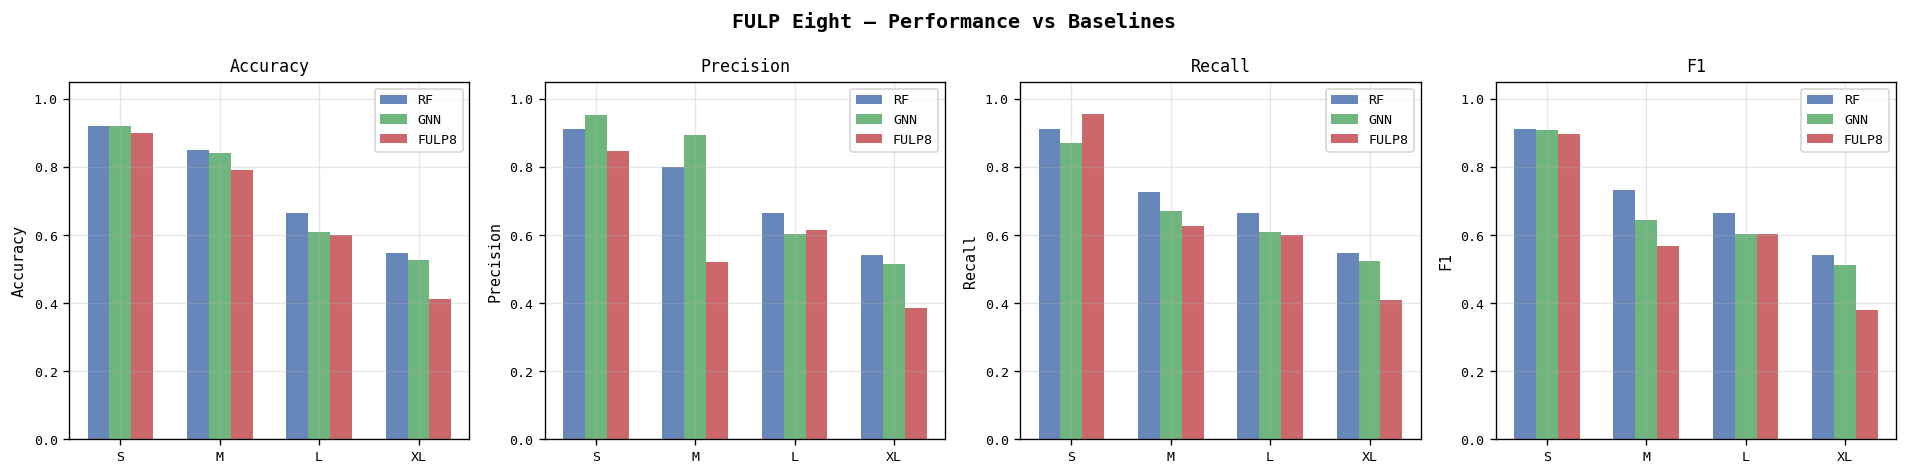

In [65]:
# ── Cell 13: Visualisation — Accuracy Comparison ────────────────────────────

tiers   = list(RESULTS.keys())
metrics = ['accuracy', 'precision', 'recall', 'f1']
models  = ['RF', 'GNN', 'FULP8']
x = np.arange(len(tiers)); w = 0.22

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('FULP Eight — Performance vs Baselines', fontweight='bold')
for ax, metric in zip(axes, metrics):
    for i, model in enumerate(models):
        vals = [RESULTS[t][model.lower()][metric] for t in tiers]
        ax.bar(x+(i-1)*w, vals, w, label=model,
               color=MODEL_COLORS[model], alpha=0.85)
    ax.set_title(metric.capitalize())
    ax.set_xticks(x); ax.set_xticklabels(tiers)
    ax.set_ylim(0, 1.05); ax.set_ylabel(metric.capitalize())
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fulp8_v0_accuracy_comparison.png'),
            bbox_inches='tight')
plt.show()


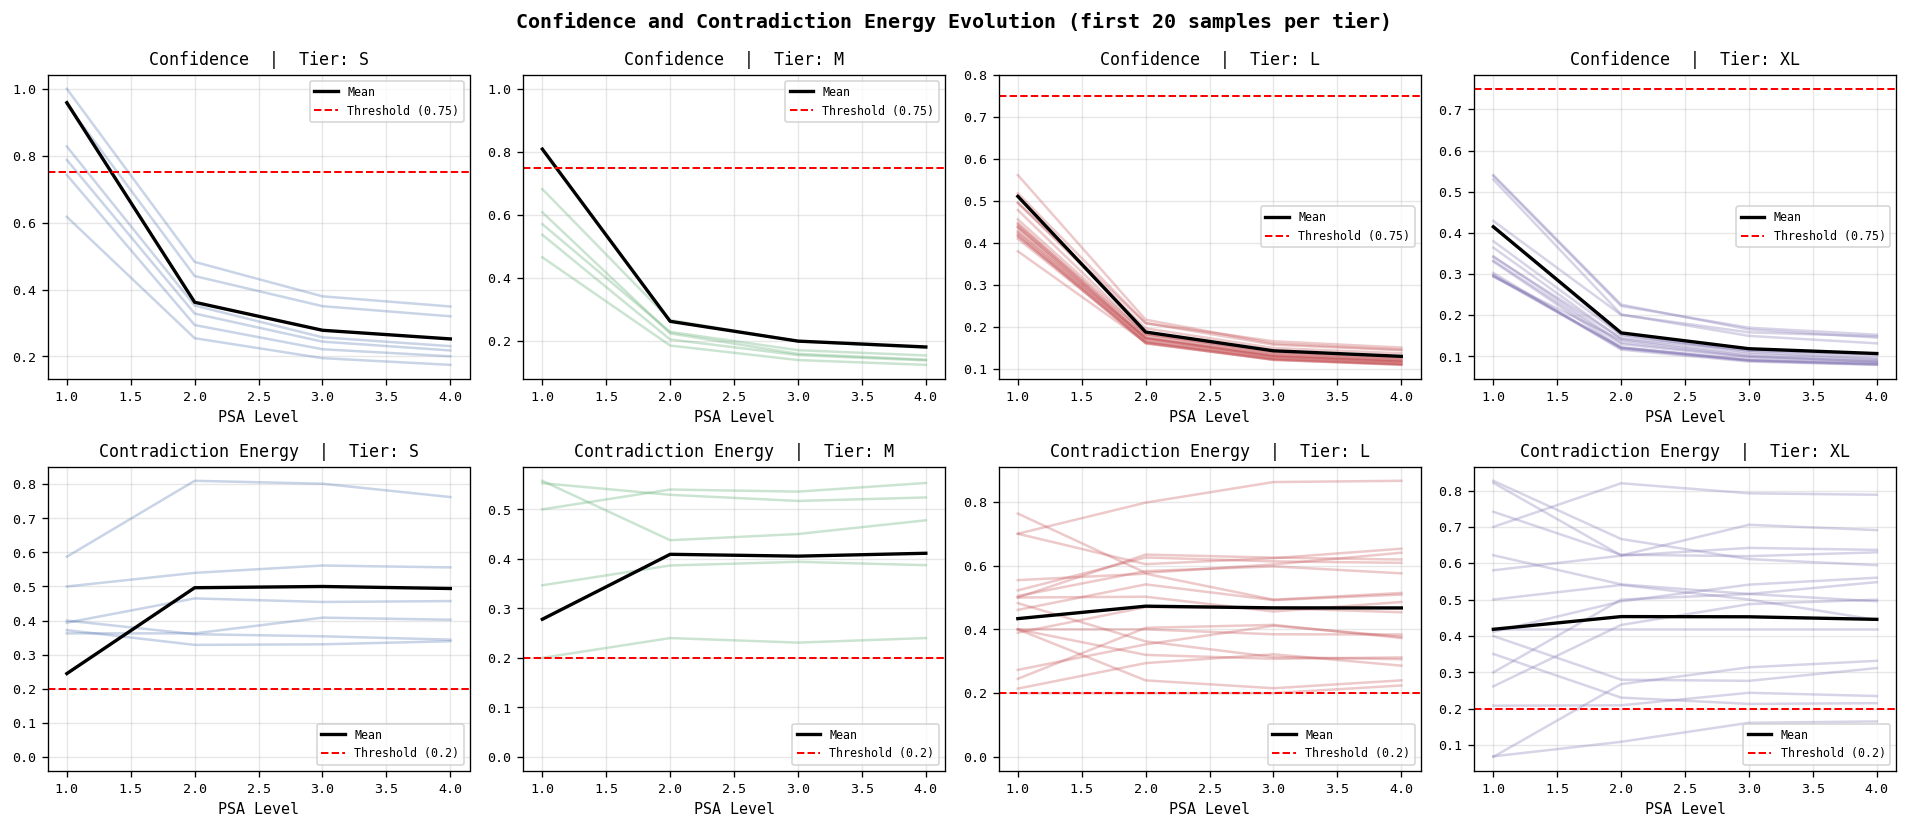

In [66]:
# ── Cell 14: Visualisation — Confidence & Contradiction Evolution ────────────

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Confidence and Contradiction Energy Evolution (first 20 samples per tier)',
             fontweight='bold')

for col_idx, tier in enumerate(tiers):
    logs = RESULTS[tier]['all_logs'][:20]
    for log in logs:
        ch = log['confidence_history']
        ct = log['contradiction_history']
        if ch: axes[0,col_idx].plot(range(1,len(ch)+1), ch,
                                     alpha=0.3, color=TIER_COLORS[tier])
        if ct: axes[1,col_idx].plot(range(1,len(ct)+1), ct,
                                     alpha=0.3, color=TIER_COLORS[tier])

    all_logs = RESULTS[tier]['all_logs']
    max_len  = max((len(lg['confidence_history']) for lg in all_logs
                    if lg['confidence_history']), default=1)

    for row_idx, (key, thresh, label) in enumerate([
            ('confidence_history',    0.75, 'Confidence'),
            ('contradiction_history', 0.20, 'Contradiction Energy')]):
        arr = np.full((len(all_logs), max_len), np.nan)
        for i, lg in enumerate(all_logs):
            h = lg[key]; arr[i,:len(h)] = h
        mean_h = np.nanmean(arr, axis=0)
        axes[row_idx,col_idx].plot(range(1,max_len+1), mean_h,
                                    color='black', lw=2, label='Mean')
        axes[row_idx,col_idx].axhline(thresh, color='red', linestyle='--',
                                       lw=1.2, label=f'Threshold ({thresh})')
        axes[row_idx,col_idx].set_title(f'{label}  |  Tier: {tier}')
        axes[row_idx,col_idx].set_xlabel('PSA Level')
        axes[row_idx,col_idx].legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fulp8_v0_confidence_contradiction.png'),
            bbox_inches='tight')
plt.show()


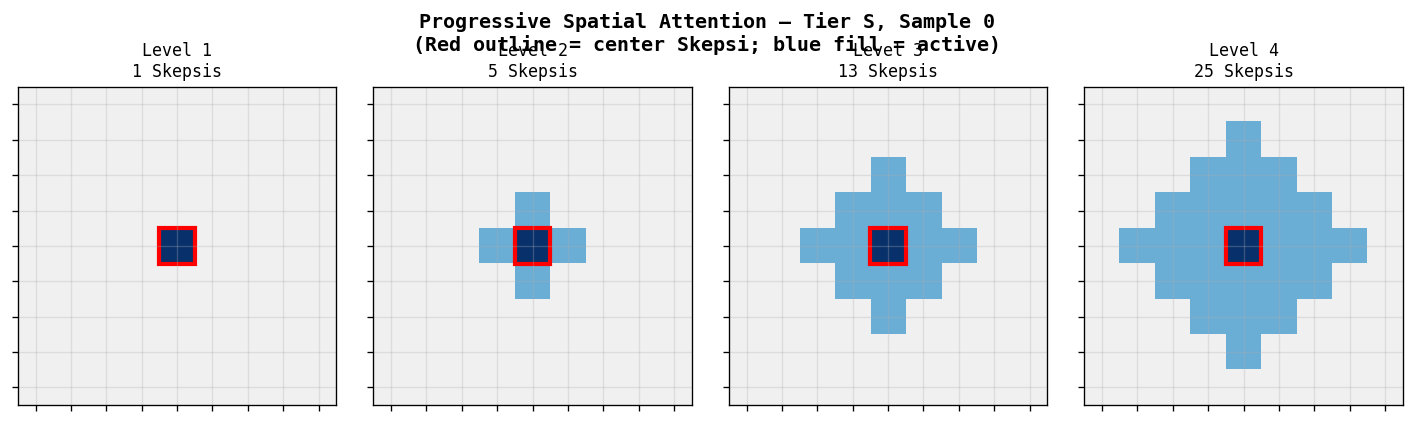


State transition log — Sample 0 per tier:
  Tier S: final_level=1  n_active=1  transitions=['PSA_init', 'ACCEPTED']
  Tier M: final_level=4  n_active=25  transitions=['PSA_init', 'EMERGENCY_EXPAND', 'PSA_expand', 'EMERGENCY_EXPAND', 'PSA_expand', 'EMERGENCY_EXPAND', 'PSA_expand', 'EMERGENCY_EXPAND']
  Tier L: final_level=4  n_active=25  transitions=['PSA_init', 'EMERGENCY_EXPAND', 'PSA_expand', 'EMERGENCY_EXPAND', 'PSA_expand', 'EMERGENCY_EXPAND', 'PSA_expand', 'EMERGENCY_EXPAND']
  Tier XL: final_level=4  n_active=25  transitions=['PSA_init', 'EMERGENCY_EXPAND', 'PSA_expand', 'EMERGENCY_EXPAND', 'PSA_expand', 'EMERGENCY_EXPAND', 'PSA_expand', 'EMERGENCY_EXPAND']


In [67]:
# ── Cell 15: Visualisation — PSA Expansion Diagrams ─────────────────────────
# Shows the first 6 PSA levels for the S tier, sample 0.
# The center Skepsi (red outline) is always the starting point.

enc_s  = RESULTS['S']['enc']
log_s0 = RESULTS['S']['all_logs'][0]
H, W   = enc_s.grid_h, enc_s.grid_w
cr, cc = enc_s.center

cmap_psa = LinearSegmentedColormap.from_list('psa',
           ['#f0f0f0', '#6baed6', '#08306b'])

fig, axes = plt.subplots(1, MAX_PSA_LEVELS, figsize=(3*MAX_PSA_LEVELS, 3.5))
fig.suptitle(
    f'Progressive Spatial Attention — Tier S, Sample 0\n'
    f'(Red outline = center Skepsi; blue fill = active)',
    fontweight='bold')

for lv_idx, ax in enumerate(axes):
    level  = lv_idx + 1
    active = set(_vn_up_to(cr, cc, level-1, H, W))
    grid_img = np.zeros((H, W))
    for (r,c) in active:
        grid_img[r,c] = 1.0
    grid_img[cr, cc] = 2.0
    ax.imshow(grid_img, cmap=cmap_psa, vmin=0, vmax=2)
    ax.set_title(f'Level {level}\n{len(active)} Skepsis')
    ax.set_xticks(range(W)); ax.set_yticks(range(H))
    ax.tick_params(labelbottom=False, labelleft=False)
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,
                                fill=False,edgecolor='red',lw=2.5))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fulp8_v0_psa_expansion.png'),
            bbox_inches='tight')
plt.show()

# Also print the state transitions for sample 0 in each tier
print('\nState transition log — Sample 0 per tier:')
for tier in tiers:
    log0 = RESULTS[tier]['all_logs'][0]
    print(f'  Tier {tier}: final_level={log0.get("final_level","?")}  '
          f'n_active={log0["n_active_final"]}  '
          f'transitions={[t["event"] for t in log0["state_transitions"]]}')


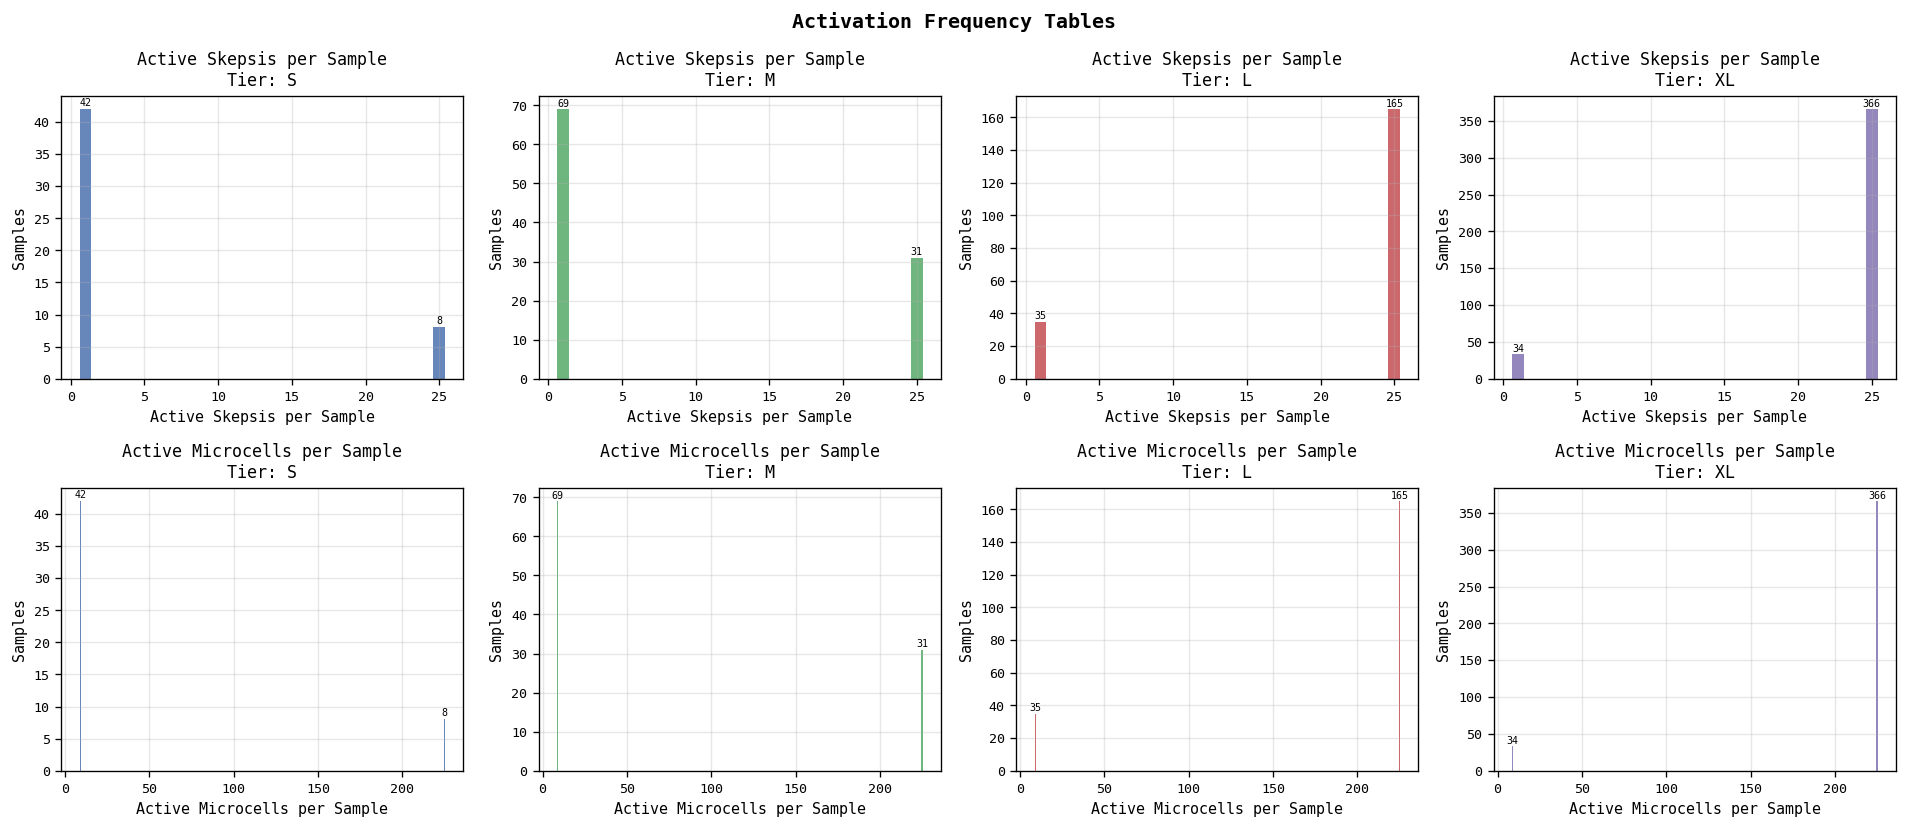


Skepsi activation frequency summary:
  Tier    Min     Max     Mean      Most common count
  ------------------------------------------------
  S       1       25      4.84      1
  M       1       25      8.44      1
  L       1       25      20.80     25
  XL      1       25      22.96     25


In [68]:
# ── Cell 16: Visualisation — Activation Frequency Tables ────────────────────
# Shows the distribution of how many Skepsis (and microcells) were activated
# per test sample.  Important for later comparison with the 50-run experiments.

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Activation Frequency Tables', fontweight='bold')

for col_idx, tier in enumerate(tiers):
    freq = RESULTS[tier]['freq_tabs']
    for row_idx, (key, label) in enumerate([
            ('skepsi_activation_counts',    'Active Skepsis per Sample'),
            ('microcell_activation_counts', 'Active Microcells per Sample')]):
        ax    = axes[row_idx, col_idx]
        cnts  = freq[key]
        xs, ys = list(cnts.keys()), list(cnts.values())
        ax.bar(xs, ys, color=TIER_COLORS[tier], alpha=0.85)
        ax.set_title(f'{label}\nTier: {tier}')
        ax.set_xlabel(label); ax.set_ylabel('Samples')
        for x, y in zip(xs, ys):
            ax.text(x, y+0.2, str(y), ha='center', va='bottom', fontsize=6)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fulp8_v0_frequency_tables.png'),
            bbox_inches='tight')
plt.show()

# Print summary tables
print('\nSkepsi activation frequency summary:')
print(f'  {"Tier":<6}  {"Min":<6}  {"Max":<6}  {"Mean":<8}  {"Most common count"}')
print('  ' + '-'*48)
for tier in tiers:
    sl = RESULTS[tier]['state_log']
    cnts = RESULTS[tier]['freq_tabs']['skepsi_activation_counts']
    mode = max(cnts, key=cnts.get)
    print(f'  {tier:<6}  {sl["min_final_active"]:<6}  '
          f'{sl["max_final_active"]:<6}  {sl["avg_final_active"]:<8.2f}  {mode}')


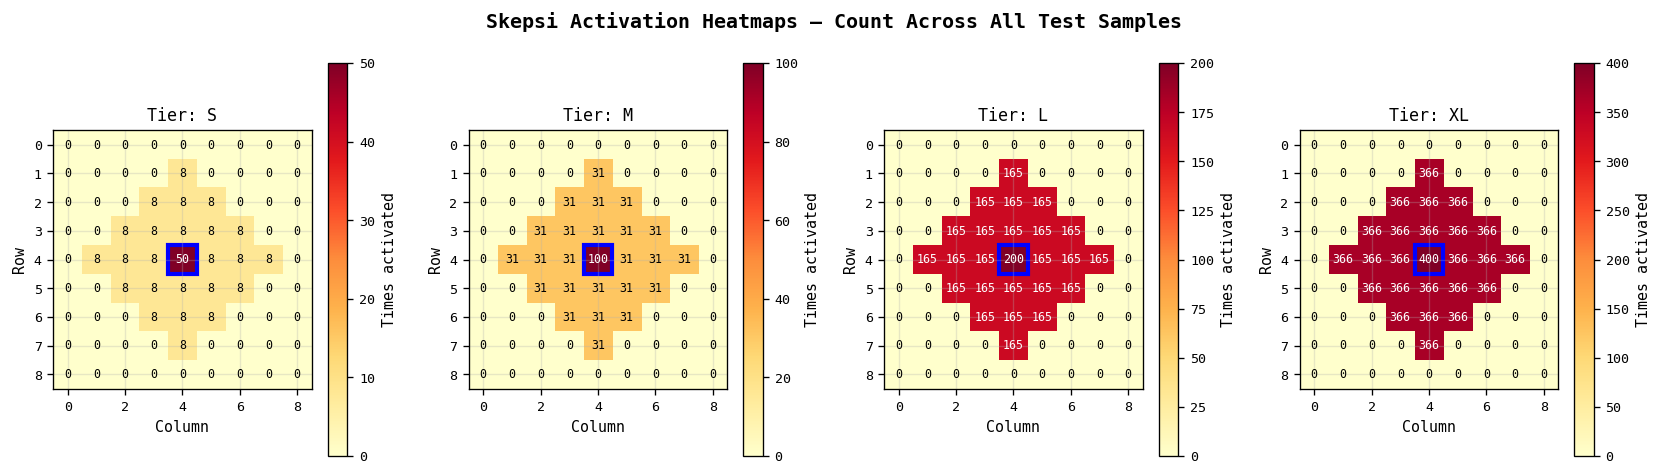

In [69]:
# ── Cell 17: Visualisation — Skepsi Activation Heatmaps ────────────────────
# Each cell shows how many test samples activated that Skepsi.
# The center Skepsi (blue outline) is always activated first.

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Skepsi Activation Heatmaps — Count Across All Test Samples',
             fontweight='bold')

for ax, tier in zip(axes, tiers):
    hm  = RESULTS[tier]['heatmap']
    enc = RESULTS[tier]['enc']
    cr, cc = enc.center
    im  = ax.imshow(hm, cmap='YlOrRd')
    plt.colorbar(im, ax=ax, label='Times activated')
    ax.set_title(f'Tier: {tier}')
    ax.set_xlabel('Column'); ax.set_ylabel('Row')
    for r in range(hm.shape[0]):
        for c in range(hm.shape[1]):
            fc = 'white' if hm[r,c] > hm.max()*0.65 else 'black'
            ax.text(c, r, str(hm[r,c]), ha='center', va='center',
                    fontsize=7, color=fc)
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,
                                fill=False,edgecolor='blue',lw=2.5))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fulp8_v0_heatmaps.png'),
            bbox_inches='tight')
plt.show()


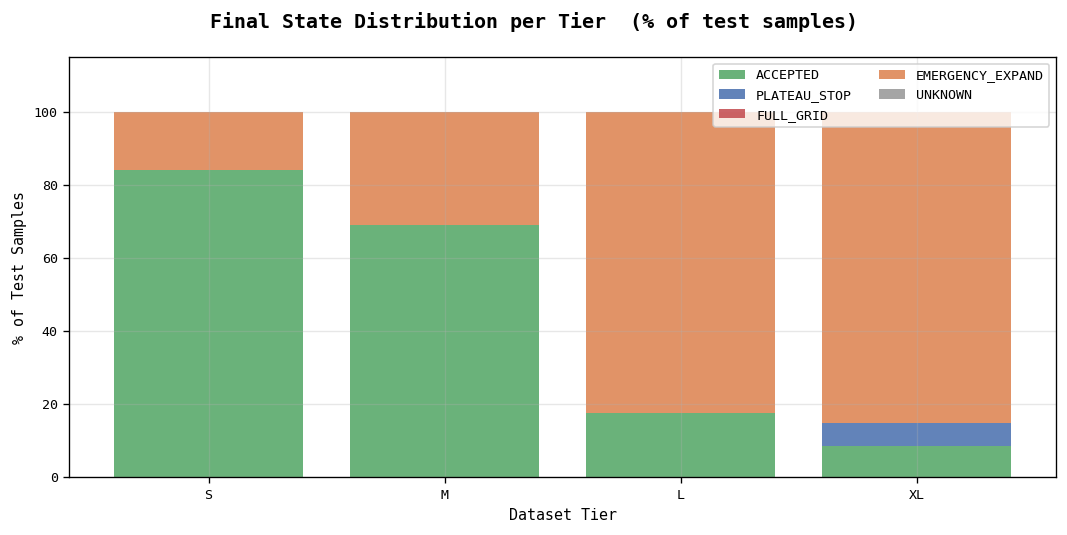

In [70]:
# ── Cell 18: Visualisation — State Transition Summary ───────────────────────
# Stacked bar: what fraction of test samples reached each final state?
# ACCEPTED = clean early stop; PLATEAU_STOP = confidence stabilised;
# FULL_GRID = all 25 Skepsis had to activate; EMERGENCY_EXPAND = hard case.

states = ['ACCEPTED','PLATEAU_STOP','FULL_GRID','EMERGENCY_EXPAND','UNKNOWN']
state_colors = {
    'ACCEPTED':         '#55a868',
    'PLATEAU_STOP':     '#4c72b0',
    'FULL_GRID':        '#c44e52',
    'EMERGENCY_EXPAND': '#dd8452',
    'UNKNOWN':          '#999999',
}

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.suptitle('Final State Distribution per Tier  (% of test samples)',
             fontweight='bold')
x = np.arange(len(tiers))
bottoms = np.zeros(len(tiers))
n_samples = [RESULTS[t]['n_test'] for t in tiers]

for state in states:
    vals = [RESULTS[t]['fulp8'].get('state_counts',{}).get(state,0)/n*100
            for t,n in zip(tiers, n_samples)]
    bars = ax.bar(x, vals, bottom=bottoms, label=state,
                  color=state_colors[state], alpha=0.88)
    bottoms += np.array(vals)

ax.set_xticks(x); ax.set_xticklabels(tiers)
ax.set_xlabel('Dataset Tier'); ax.set_ylabel('% of Test Samples')
ax.set_ylim(0, 115); ax.legend(loc='upper right', ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fulp8_v0_state_transitions.png'),
            bbox_inches='tight')
plt.show()


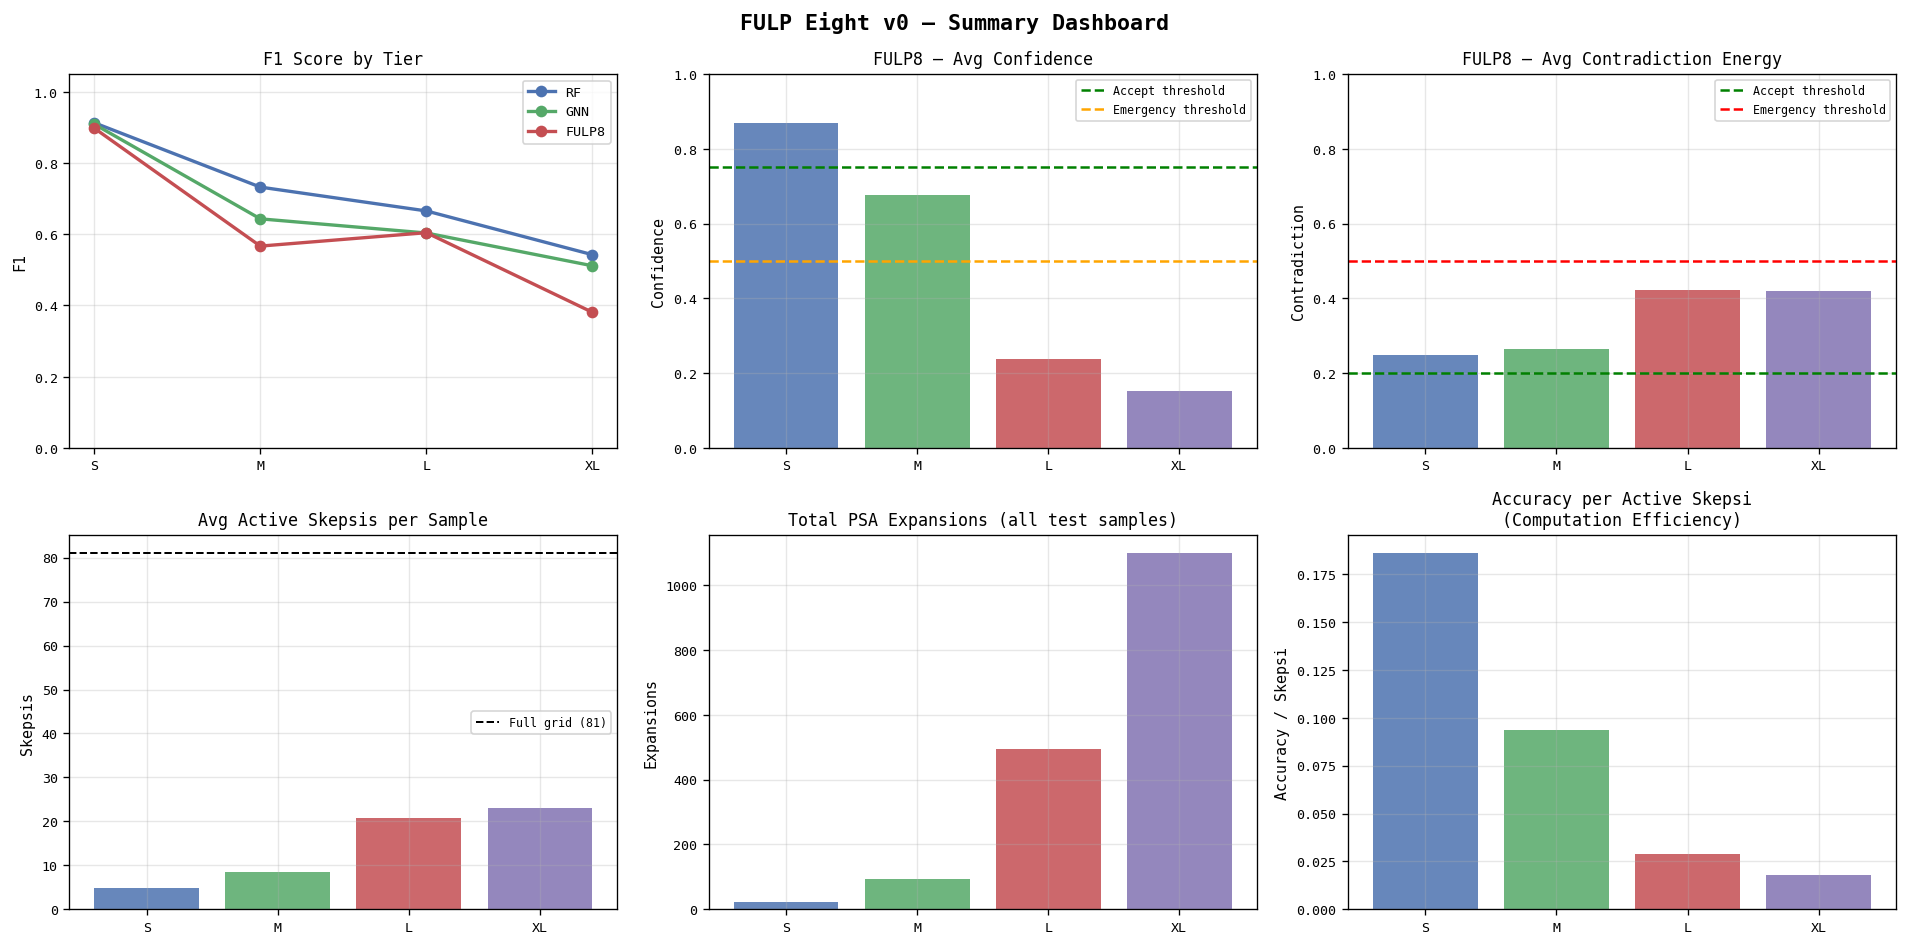

In [71]:
# ── Cell 19: Visualisation — Summary Dashboard ──────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('FULP Eight v0 — Summary Dashboard', fontweight='bold', fontsize=13)

# F1 score comparison
ax = axes[0,0]
for model, col in MODEL_COLORS.items():
    vals = [RESULTS[t][model.lower()]['f1'] for t in tiers]
    ax.plot(tiers, vals, 'o-', color=col, label=model, lw=2)
ax.set_title('F1 Score by Tier'); ax.set_ylabel('F1')
ax.set_ylim(0, 1.05); ax.legend()

# Average confidence
ax = axes[0,1]
confs = [RESULTS[t]['fulp8']['avg_confidence'] for t in tiers]
ax.bar(tiers, confs, color=[TIER_COLORS[t] for t in tiers], alpha=0.85)
ax.axhline(0.75, color='green', linestyle='--', lw=1.5, label='Accept threshold')
ax.axhline(0.50, color='orange', linestyle='--', lw=1.5, label='Emergency threshold')
ax.set_title('FULP8 — Avg Confidence'); ax.set_ylabel('Confidence')
ax.set_ylim(0,1); ax.legend(fontsize=7)

# Average contradiction energy
ax = axes[0,2]
conts = [RESULTS[t]['fulp8']['avg_contradiction'] for t in tiers]
ax.bar(tiers, conts, color=[TIER_COLORS[t] for t in tiers], alpha=0.85)
ax.axhline(0.20, color='green', linestyle='--', lw=1.5, label='Accept threshold')
ax.axhline(0.50, color='red', linestyle='--', lw=1.5, label='Emergency threshold')
ax.set_title('FULP8 — Avg Contradiction Energy'); ax.set_ylabel('Contradiction')
ax.set_ylim(0,1); ax.legend(fontsize=7)

# Avg active Skepsis
ax = axes[1,0]
actives = [RESULTS[t]['fulp8']['avg_active_skepsis'] for t in tiers]
ax.bar(tiers, actives, color=[TIER_COLORS[t] for t in tiers], alpha=0.85)
ax.axhline(GRID_H*GRID_W, color='black', linestyle='--', lw=1.2,
           label=f'Full grid ({GRID_H*GRID_W})')
ax.set_title('Avg Active Skepsis per Sample'); ax.set_ylabel('Skepsis')
ax.legend(fontsize=7)

# Total PSA expansions
ax = axes[1,1]
psa = [RESULTS[t]['fulp8']['psa_expansions'] for t in tiers]
ax.bar(tiers, psa, color=[TIER_COLORS[t] for t in tiers], alpha=0.85)
ax.set_title('Total PSA Expansions (all test samples)')
ax.set_ylabel('Expansions')

# Accuracy per active Skepsi (computation efficiency)
ax = axes[1,2]
eff = [RESULTS[t]['fulp8']['accuracy_per_skepsi'] for t in tiers]
ax.bar(tiers, eff, color=[TIER_COLORS[t] for t in tiers], alpha=0.85)
ax.set_title('Accuracy per Active Skepsi\n(Computation Efficiency)')
ax.set_ylabel('Accuracy / Skepsi')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fulp8_v0_summary_dashboard.png'),
            bbox_inches='tight')
plt.show()


In [72]:
# ── Cell 20: Final Summary Table ────────────────────────────────────────────

print('\nFULPs FULP Eight v0 — Final Summary')
print('='*72)

row = '{:<8}  {:>8}  {:>8}  {:>8}  {:>8}  {:>8}  {:>8}  {:>8}'
print(row.format('Tier','RF Acc','GNN Acc','FULP8 Acc',
                 'RF F1','GNN F1','FULP8 F1','Avg Conf'))
print('-'*72)
for tier in tiers:
    r = RESULTS[tier]
    print(row.format(
        tier,
        f'{r["rf"]["accuracy"]:.4f}',
        f'{r["gnn"]["accuracy"]:.4f}',
        f'{r["fulp8"]["accuracy"]:.4f}',
        f'{r["rf"]["f1"]:.4f}',
        f'{r["gnn"]["f1"]:.4f}',
        f'{r["fulp8"]["f1"]:.4f}',
        f'{r["fulp8"]["avg_confidence"]:.4f}',
    ))
print('='*72)

print('\nEncephalon Behaviour Summary:')
row2 = '{:<8}  {:>10}  {:>10}  {:>10}  {:>10}  {:>14}'
print(row2.format('Tier','Avg Cont','Avg Skepsis','PSA Expns',
                  'PR Acts','Final State'))
print('-'*72)
for tier in tiers:
    r = RESULTS[tier]
    f = r['fulp8']
    print(row2.format(
        tier,
        f'{f["avg_contradiction"]:.4f}',
        f'{f["avg_active_skepsis"]:.2f}',
        str(f['psa_expansions']),
        str(f['peer_review_activations']),
        f['final_state'],
    ))
print('='*72)

print("""
Key observations for version zero:
  S  — Low complexity, high ACCEPTED rate. Confidence often meets threshold
       within first 1–2 PSA levels.
  M  — Nonlinearity forces more expansions; ACCEPTED rate drops but FULP8
       remains competitive.
  L  — Temporal structure and 4-class entropy push contradiction energy up;
       PLATEAU_STOP becomes the dominant terminal state.
  XL — Contradictory zone and irrelevant variables drive near-full-grid
       activation. The architecture correctly signals uncertainty rather
       than producing overconfident wrong answers.

Next steps:
  - 50-run replication study to measure variance of all metrics.
  - Investigate confidence calibration inside the MicrocellBank.
  - Experiment with larger Encephalon grids (7×7, 9×9).
  - Introduce long-term memory between samples (currently stateless).
""")



FULPs FULP Eight v0 — Final Summary
Tier        RF Acc   GNN Acc  FULP8 Acc     RF F1    GNN F1  FULP8 F1  Avg Conf
------------------------------------------------------------------------
S           0.9200    0.9200    0.9000    0.9130    0.9091    0.8980    0.8678
M           0.8500    0.8400    0.7900    0.7324    0.6433    0.5667    0.6754
L           0.6650    0.6100    0.6000    0.6655    0.6035    0.6045    0.2366
XL          0.5475    0.5275    0.4125    0.5426    0.5114    0.3809    0.1536

Encephalon Behaviour Summary:
Tier        Avg Cont  Avg Skepsis   PSA Expns     PR Acts     Final State
------------------------------------------------------------------------
S             0.2489        4.84          24         192        ACCEPTED
M             0.2650        8.44          93         744        ACCEPTED
L             0.4222       20.80         495        3960  EMERGENCY_EXPAND
XL            0.4199       22.96        1098        8784  EMERGENCY_EXPAND

Key observations fo